T1.2 — CELL 1: EMPIRICAL DOSE-RESPONSE AUDIT

✓ 30 final-checkpoint models loaded
✓ Six rho levels
✓ Five replicates per rho

PART A — RHO-LEVEL SUMMARY

Δz_hair
------------------------------------------------------------
     rho  n      mean       sd  ci95_low  ci95_high       min       max
0.000000  5  1.772816 0.134888  1.605331   1.940301  1.563364  1.904324
0.200000  5  5.070306 0.229932  4.784808   5.355804  4.803006  5.292174
0.400000  5  6.324957 0.228879  6.040766   6.609148  6.037012  6.646714
0.600000  5  7.754494 0.226043  7.473825   8.035164  7.460529  8.018230
0.800000  5 10.004132 0.082251  9.902004  10.106261  9.918443 10.107501
1.000000  5 12.315926 0.418447 11.796356  12.835496 11.847715 12.842734

D = BA_clean − BA_reversed
------------------------------------------------------------
     rho  n     mean       sd  ci95_low  ci95_high      min      max
0.000000  5 0.021531 0.002198  0.018802   0.024260 0.019748 0.025341
0.200000  5 0.089864 0.005297  0.083286   0.09

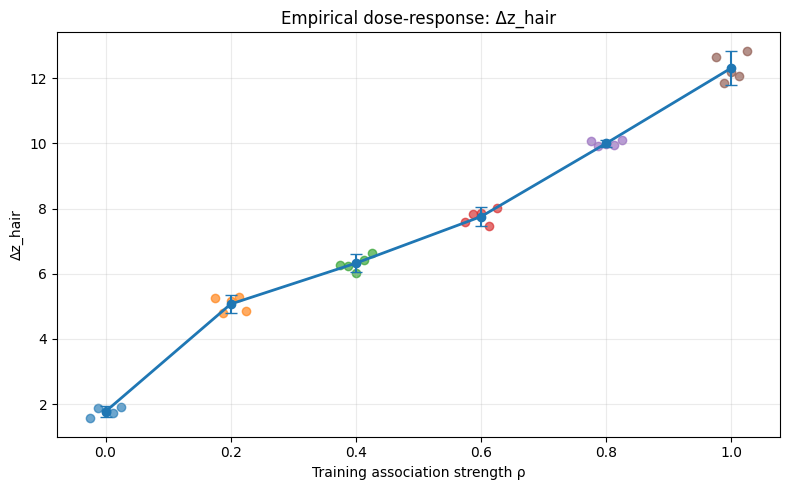

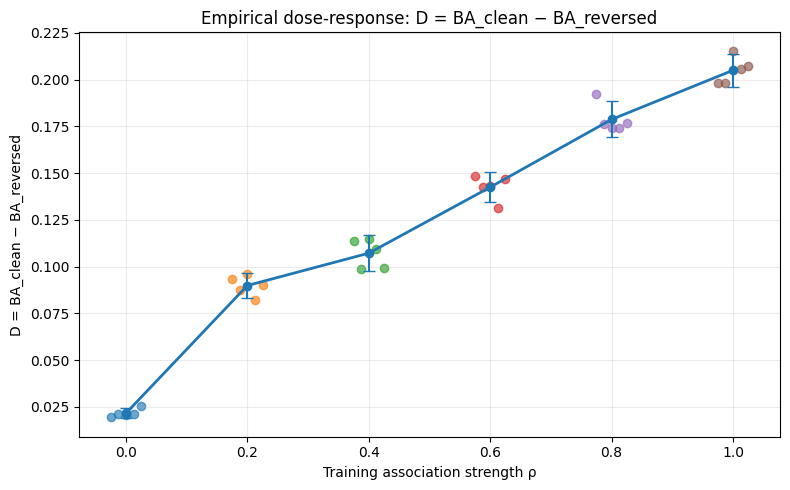

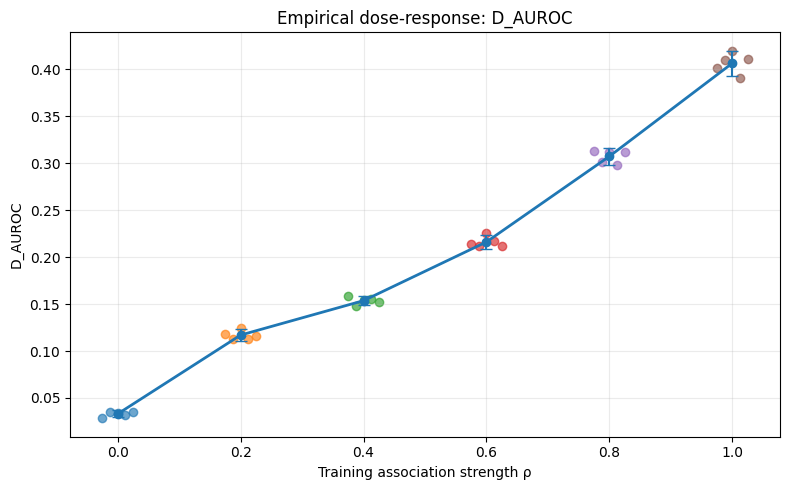

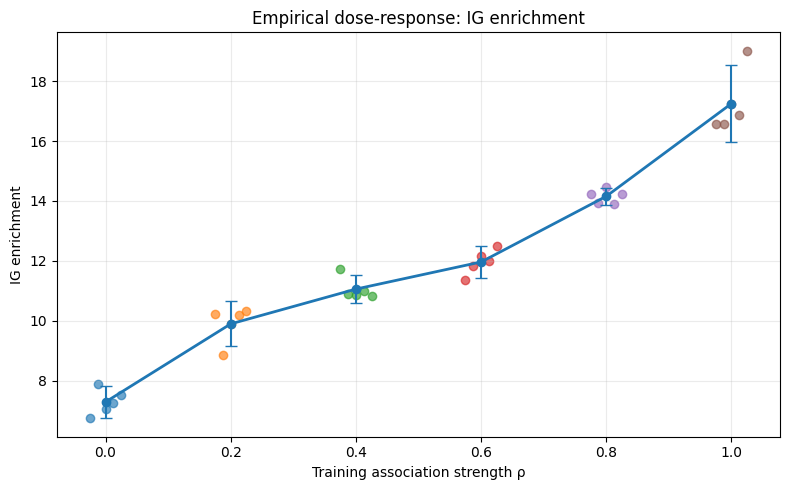


CELL 1 COMPLETE

Next:

Inspect the six empirical dose-response means and
adjacent increments before fitting ANY curve.

Do not fit linear/logistic/Hill/spline models yet.



In [1]:
# ======================================================================
# T1.2 — CELL 1: EMPIRICAL DOSE-RESPONSE AUDIT
# ======================================================================

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

print("=" * 70)
print("T1.2 — CELL 1: EMPIRICAL DOSE-RESPONSE AUDIT")
print("=" * 70)

# ----------------------------------------------------------------------
# 0. Load locked final-checkpoint endpoint table
# ----------------------------------------------------------------------

CSV_PATH = Path(
    "/kaggle/input/notebooks/tejasseshadriiiii/"
    "isic-kaggle-analysis/results/"
    "model_endpoints_final_checkpoint.csv"
)

df = pd.read_csv(CSV_PATH)

assert len(df) == 30

RHO_LEVELS = np.array(
    [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
)

assert np.allclose(
    np.sort(df["rho"].unique()),
    RHO_LEVELS
)

assert all(
    df.groupby("rho").size().to_numpy() == 5
)

print("\n✓ 30 final-checkpoint models loaded")
print("✓ Six rho levels")
print("✓ Five replicates per rho")

# ----------------------------------------------------------------------
# 1. Endpoints to audit
# ----------------------------------------------------------------------

ENDPOINTS = [
    "delta_z_hair",
    "D",
    "D_AUROC",
    "xai_enrichment",
]

LABELS = {
    "delta_z_hair":
        "Δz_hair",

    "D":
        "D = BA_clean − BA_reversed",

    "D_AUROC":
        "D_AUROC",

    "xai_enrichment":
        "IG enrichment",
}

# ----------------------------------------------------------------------
# 2. Group statistics
# ----------------------------------------------------------------------

summary_rows = []

for rho in RHO_LEVELS:

    sub = df[
        np.isclose(df["rho"], rho)
    ]

    assert len(sub) == 5

    for endpoint in ENDPOINTS:

        values = sub[endpoint].to_numpy(
            dtype=float
        )

        mean = values.mean()
        sd = values.std(ddof=1)

        se = sd / np.sqrt(len(values))

        # t critical for df=4
        # scipy is used rather than hard-coding.
        from scipy.stats import t

        tcrit = t.ppf(
            0.975,
            df=len(values) - 1
        )

        ci_low = mean - tcrit * se
        ci_high = mean + tcrit * se

        summary_rows.append({
            "rho": rho,
            "endpoint": endpoint,
            "n": len(values),
            "mean": mean,
            "sd": sd,
            "se": se,
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "min": values.min(),
            "max": values.max(),
        })

summary = pd.DataFrame(
    summary_rows
)

# ----------------------------------------------------------------------
# 3. Print group means and uncertainty
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART A — RHO-LEVEL SUMMARY")
print("=" * 70)

for endpoint in ENDPOINTS:

    print(f"\n{LABELS[endpoint]}")
    print("-" * 60)

    sub = summary[
        summary["endpoint"] == endpoint
    ]

    print(
        sub[
            [
                "rho",
                "n",
                "mean",
                "sd",
                "ci95_low",
                "ci95_high",
                "min",
                "max",
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )

# ----------------------------------------------------------------------
# 4. Adjacent dose increments
#
# This is important for identifying:
#
#   approximately linear:
#       similar increments
#
#   saturation:
#       increments become progressively smaller
#
#   acceleration:
#       increments become progressively larger
#
# This remains descriptive.
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART B — ADJACENT DOSE INCREMENTS")
print("=" * 70)

increment_rows = []

for endpoint in ENDPOINTS:

    means = (
        summary[
            summary["endpoint"] == endpoint
        ]
        .sort_values("rho")["mean"]
        .to_numpy()
    )

    increments = np.diff(means)

    print(f"\n{LABELS[endpoint]}")

    for i, inc in enumerate(increments):

        print(
            f"  {RHO_LEVELS[i]:.1f} → "
            f"{RHO_LEVELS[i+1]:.1f}: "
            f"Δmean = {inc:+.6f}"
        )

        increment_rows.append({
            "endpoint": endpoint,
            "rho_start": RHO_LEVELS[i],
            "rho_end": RHO_LEVELS[i + 1],
            "mean_increment": inc,
        })

increments_df = pd.DataFrame(
    increment_rows
)

# ----------------------------------------------------------------------
# 5. Replicate-level table
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART C — ALL 30 REPLICATE VALUES")
print("=" * 70)

for endpoint in ENDPOINTS:

    print(f"\n{LABELS[endpoint]}")

    wide = (
        df[
            [
                "rho",
                "replicate",
                endpoint,
            ]
        ]
        .sort_values(
            ["rho", "replicate"]
        )
        .pivot(
            index="rho",
            columns="replicate",
            values=endpoint
        )
    )

    print(
        wide.to_string(
            float_format=lambda x: f"{x:.6f}"
        )
    )

# ----------------------------------------------------------------------
# 6. Plot empirical dose-response
#
# Individual model points + group mean + 95% CI.
#
# NO fitted nonlinear curve.
# ----------------------------------------------------------------------

for endpoint in ENDPOINTS:

    sub_summary = summary[
        summary["endpoint"] == endpoint
    ].sort_values("rho")

    plt.figure(
        figsize=(8, 5)
    )

    # Individual model points
    for rho in RHO_LEVELS:

        vals = df[
            np.isclose(df["rho"], rho)
        ][endpoint].to_numpy()

        # Small deterministic horizontal offsets
        offsets = np.linspace(
            -0.025,
            0.025,
            len(vals)
        )

        plt.scatter(
            np.full(len(vals), rho) + offsets,
            vals,
            alpha=0.65
        )

    # Mean
    plt.plot(
        sub_summary["rho"],
        sub_summary["mean"],
        marker="o",
        linewidth=2,
        label="Mean"
    )

    # 95% CI
    yerr = np.vstack([
        sub_summary["mean"]
        - sub_summary["ci95_low"],

        sub_summary["ci95_high"]
        - sub_summary["mean"],
    ])

    plt.errorbar(
        sub_summary["rho"],
        sub_summary["mean"],
        yerr=yerr,
        fmt="none",
        capsize=4
    )

    plt.xlabel("Training association strength ρ")
    plt.ylabel(LABELS[endpoint])
    plt.title(
        f"Empirical dose-response: {LABELS[endpoint]}"
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.show()

# ----------------------------------------------------------------------
# 7. Save
# ----------------------------------------------------------------------

OUT = Path(
    "/kaggle/working/t1_2_results"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)

summary.to_csv(
    OUT / "rho_level_dose_response_summary.csv",
    index=False
)

increments_df.to_csv(
    OUT / "adjacent_dose_increments.csv",
    index=False
)

print("\n" + "=" * 70)
print("CELL 1 COMPLETE")
print("=" * 70)

print("""
Next:

Inspect the six empirical dose-response means and
adjacent increments before fitting ANY curve.

Do not fit linear/logistic/Hill/spline models yet.
""")

In [2]:
# ======================================================================
# T1.2 — CELL 2: LINEAR vs QUADRATIC DOSE-RESPONSE SHAPE
# ======================================================================

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats

print("=" * 70)
print("T1.2 — CELL 2: LINEAR vs QUADRATIC DOSE-RESPONSE SHAPE")
print("=" * 70)

# ----------------------------------------------------------------------
# 0. Load data
# ----------------------------------------------------------------------

CSV_PATH = Path(
    "/kaggle/input/notebooks/tejasseshadriiiii/"
    "isic-kaggle-analysis/results/"
    "model_endpoints_final_checkpoint.csv"
)

df = pd.read_csv(CSV_PATH)

assert len(df) == 30

RHO = df["rho"].to_numpy(dtype=float)

ENDPOINTS = [
    "delta_z_hair",
    "D",
    "D_AUROC",
    "xai_enrichment",
]

LABELS = {
    "delta_z_hair": "Δz_hair",
    "D": "D",
    "D_AUROC": "D_AUROC",
    "xai_enrichment": "IG enrichment",
}

RHO_LEVELS = np.array(
    [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
)

# ----------------------------------------------------------------------
# 1. Helper: ordinary least-squares polynomial fit
# ----------------------------------------------------------------------

def fit_polynomial(x, y, degree):

    X = np.column_stack([
        x ** k
        for k in range(degree + 1)
    ])

    beta, residuals, rank, s = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )

    fitted = X @ beta

    residual = y - fitted

    SSE = np.sum(residual ** 2)

    SST = np.sum(
        (y - np.mean(y)) ** 2
    )

    R2 = 1.0 - SSE / SST

    n = len(y)
    p = degree + 1

    if n > p:
        sigma2 = SSE / (n - p)

        cov_beta = (
            sigma2 *
            np.linalg.inv(X.T @ X)
        )

        se_beta = np.sqrt(
            np.diag(cov_beta)
        )

        t_stats = beta / se_beta

        p_values = (
            2 *
            stats.t.sf(
                np.abs(t_stats),
                df=n-p
            )
        )

    else:
        se_beta = np.full_like(
            beta,
            np.nan
        )

        p_values = np.full_like(
            beta,
            np.nan
        )

    return {
        "beta": beta,
        "se": se_beta,
        "p": p_values,
        "fitted": fitted,
        "SSE": SSE,
        "R2": R2,
        "n": n,
        "p_parameters": p,
    }


# ----------------------------------------------------------------------
# 2. Fit linear and quadratic models
# ----------------------------------------------------------------------

results = []

for endpoint in ENDPOINTS:

    y = df[endpoint].to_numpy(
        dtype=float
    )

    linear = fit_polynomial(
        RHO,
        y,
        degree=1
    )

    quadratic = fit_polynomial(
        RHO,
        y,
        degree=2
    )

    # Nested-model F test:
    #
    # linear:
    #     y = b0 + b1*rho
    #
    # quadratic:
    #     y = b0 + b1*rho + b2*rho²
    #
    # Additional parameter = one.

    SSE_linear = linear["SSE"]
    SSE_quad = quadratic["SSE"]

    df_num = 1
    df_den = len(y) - 3

    F = (
        (SSE_linear - SSE_quad)
        / df_num
    ) / (
        SSE_quad / df_den
    )

    p_F = stats.f.sf(
        F,
        df_num,
        df_den
    )

    results.append({
        "endpoint": endpoint,

        "linear_slope":
            linear["beta"][1],

        "linear_R2":
            linear["R2"],

        "quadratic_linear_term":
            quadratic["beta"][1],

        "quadratic_term":
            quadratic["beta"][2],

        "quadratic_term_SE":
            quadratic["se"][2],

        "quadratic_term_p":
            quadratic["p"][2],

        "quadratic_R2":
            quadratic["R2"],

        "delta_R2":
            quadratic["R2"] -
            linear["R2"],

        "SSE_linear":
            SSE_linear,

        "SSE_quadratic":
            SSE_quad,

        "nested_F":
            F,

        "nested_p":
            p_F,
    })

shape_results = pd.DataFrame(
    results
)

# ----------------------------------------------------------------------
# 3. Print results
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART A — LINEAR vs QUADRATIC")
print("=" * 70)

print(
    shape_results[
        [
            "endpoint",
            "linear_slope",
            "linear_R2",
            "quadratic_term",
            "quadratic_term_SE",
            "quadratic_term_p",
            "quadratic_R2",
            "delta_R2",
            "nested_F",
            "nested_p",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ----------------------------------------------------------------------
# 4. Interpret curvature direction
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART B — CURVATURE DIRECTION")
print("=" * 70)

for _, row in shape_results.iterrows():

    b2 = row["quadratic_term"]

    if b2 > 0:
        direction = "UPWARD curvature / acceleration"
    elif b2 < 0:
        direction = "DOWNWARD curvature / saturation"
    else:
        direction = "approximately linear"

    print(
        f"{LABELS[row['endpoint']]:20s}: "
        f"beta2={b2:+.6f} → {direction}"
    )

# ----------------------------------------------------------------------
# 5. Group-mean quadratic fit
#
# This is a descriptive check using the six empirical means rather
# than the 30 individual models.
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART C — QUADRATIC FIT TO SIX GROUP MEANS")
print("=" * 70)

group_rows = []

for endpoint in ENDPOINTS:

    means = (
        df
        .groupby("rho")[endpoint]
        .mean()
        .reindex(RHO_LEVELS)
        .to_numpy()
    )

    linear_g = fit_polynomial(
        RHO_LEVELS,
        means,
        degree=1
    )

    quadratic_g = fit_polynomial(
        RHO_LEVELS,
        means,
        degree=2
    )

    group_rows.append({
        "endpoint": endpoint,
        "linear_R2_group_means":
            linear_g["R2"],
        "quadratic_R2_group_means":
            quadratic_g["R2"],
        "delta_R2_group_means":
            quadratic_g["R2"] -
            linear_g["R2"],
        "quadratic_term_group_means":
            quadratic_g["beta"][2],
    })

group_shape = pd.DataFrame(
    group_rows
)

print(
    group_shape.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ----------------------------------------------------------------------
# 6. Save
# ----------------------------------------------------------------------

OUT = Path(
    "/kaggle/working/t1_2_results"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)

shape_results.to_csv(
    OUT / "linear_vs_quadratic_shape.csv",
    index=False
)

group_shape.to_csv(
    OUT / "group_mean_linear_vs_quadratic.csv",
    index=False
)

print("\n" + "=" * 70)
print("CELL 2 COMPLETE")
print("=" * 70)

print("""
Interpretation rule:

Do NOT automatically declare a nonlinear dose-response
just because quadratic R² is slightly larger.

We will consider:
  • sign of beta2
  • magnitude of delta R²
  • nested-model p-value
  • consistency between 30-model and six-group-mean fits
  • empirical adjacent increments

Only after that will we decide whether a more specific
nonlinear model is justified.
""")

T1.2 — CELL 2: LINEAR vs QUADRATIC DOSE-RESPONSE SHAPE

PART A — LINEAR vs QUADRATIC
      endpoint  linear_slope  linear_R2  quadratic_term  quadratic_term_SE  quadratic_term_p  quadratic_R2  delta_R2  nested_F  nested_p
  delta_z_hair      9.849509   0.978745       -0.423451           0.952776          0.660267      0.978899  0.000154  0.197527  0.660267
             D      0.174170   0.963369       -0.060028           0.019162          0.004140      0.973134  0.009765  9.813794  0.004140
       D_AUROC      0.357482   0.978095        0.131367           0.024557          0.000012      0.989366  0.011271 28.617903  0.000012
xai_enrichment      9.073338   0.939669        2.932162           1.405591          0.046550      0.948043  0.008374  4.351693  0.046550

PART B — CURVATURE DIRECTION
Δz_hair             : beta2=-0.423451 → DOWNWARD curvature / saturation
D                   : beta2=-0.060028 → DOWNWARD curvature / saturation
D_AUROC             : beta2=+0.131367 → UPWARD curvature

In [3]:
# ======================================================================
# T1.2 — CELL 3: CURVATURE ROBUSTNESS AUDIT
# ======================================================================

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats

print("=" * 70)
print("T1.2 — CELL 3: CURVATURE ROBUSTNESS AUDIT")
print("=" * 70)

# ----------------------------------------------------------------------
# 0. Load data
# ----------------------------------------------------------------------

CSV_PATH = Path(
    "/kaggle/input/notebooks/tejasseshadriiiii/"
    "isic-kaggle-analysis/results/"
    "model_endpoints_final_checkpoint.csv"
)

df = pd.read_csv(CSV_PATH)

assert len(df) == 30

ENDPOINTS = [
    "delta_z_hair",
    "D",
    "D_AUROC",
    "xai_enrichment",
]

RHO_LEVELS = np.array(
    [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
)

# ----------------------------------------------------------------------
# 1. Polynomial fitting helper
# ----------------------------------------------------------------------

def quadratic_fit(x, y):

    X = np.column_stack([
        np.ones(len(x)),
        x,
        x**2
    ])

    beta, _, _, _ = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )

    fitted = X @ beta

    residual = y - fitted

    SSE = np.sum(
        residual**2
    )

    n = len(y)
    p = 3

    sigma2 = SSE / (n - p)

    cov_beta = (
        sigma2 *
        np.linalg.inv(X.T @ X)
    )

    se = np.sqrt(
        np.diag(cov_beta)
    )

    t_stat = beta[2] / se[2]

    p_value = (
        2 *
        stats.t.sf(
            abs(t_stat),
            df=n-p
        )
    )

    return {
        "beta0": beta[0],
        "beta1": beta[1],
        "beta2": beta[2],
        "se_beta2": se[2],
        "p_beta2": p_value,
        "R2": (
            1 -
            SSE /
            np.sum(
                (y - y.mean())**2
            )
        ),
    }


# ----------------------------------------------------------------------
# PART A — Holm correction
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART A — HOLM CORRECTION OF QUADRATIC TESTS")
print("=" * 70)

raw_p = np.array([
    0.660267,   # delta_z_hair
    0.004140,   # D
    0.000012,   # D_AUROC
    0.046550,   # IG
])

endpoint_order = ENDPOINTS.copy()

# Holm-Bonferroni
order = np.argsort(raw_p)

holm = np.empty_like(raw_p)

running_max = 0.0

m = len(raw_p)

for rank, idx in enumerate(order):

    adjusted = (
        (m - rank) *
        raw_p[idx]
    )

    running_max = max(
        running_max,
        adjusted
    )

    holm[idx] = min(
        running_max,
        1.0
    )

holm_table = pd.DataFrame({
    "endpoint": endpoint_order,
    "raw_p": raw_p,
    "holm_p": holm,
    "reject_alpha_0.05":
        holm < 0.05,
})

print(
    holm_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.8f}"
    )
)

# ----------------------------------------------------------------------
# PART B — Leave-one-replicate-out quadratic fits
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART B — LEAVE-ONE-REPLICATE-OUT CURVATURE")
print("=" * 70)

loo_rows = []

for endpoint in ENDPOINTS:

    for removed_rep in sorted(
        df["replicate"].unique()
    ):

        sub = df[
            df["replicate"] != removed_rep
        ]

        fit = quadratic_fit(
            sub["rho"].to_numpy(),
            sub[endpoint].to_numpy()
        )

        loo_rows.append({
            "endpoint": endpoint,
            "removed_replicate":
                int(removed_rep),
            "beta2":
                fit["beta2"],
            "p_beta2":
                fit["p_beta2"],
            "R2":
                fit["R2"],
        })

loo = pd.DataFrame(
    loo_rows
)

for endpoint in ENDPOINTS:

    print(f"\n{endpoint}")

    sub = loo[
        loo["endpoint"] == endpoint
    ]

    print(
        sub[
            [
                "removed_replicate",
                "beta2",
                "p_beta2",
                "R2",
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )

    beta2_values = sub["beta2"].to_numpy()

    print(
        f"  beta2 range: "
        f"[{beta2_values.min():+.6f}, "
        f"{beta2_values.max():+.6f}]"
    )

    print(
        f"  same-sign fits: "
        f"{np.sum(np.sign(beta2_values) == np.sign(beta2_values.mean()))}"
        f"/{len(beta2_values)}"
    )

# ----------------------------------------------------------------------
# PART C — Directional stability
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART C — CURVATURE DIRECTION STABILITY")
print("=" * 70)

direction_rows = []

for endpoint in ENDPOINTS:

    sub = loo[
        loo["endpoint"] == endpoint
    ]

    beta2 = sub["beta2"].to_numpy()

    direction_rows.append({
        "endpoint": endpoint,
        "positive_beta2": int(
            np.sum(beta2 > 0)
        ),
        "negative_beta2": int(
            np.sum(beta2 < 0)
        ),
        "min_beta2": beta2.min(),
        "max_beta2": beta2.max(),
        "median_beta2": np.median(beta2),
    })

direction = pd.DataFrame(
    direction_rows
)

print(
    direction.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ----------------------------------------------------------------------
# PART D — Permutation test for quadratic curvature
#
# Null hypothesis:
# The observed endpoint values have no systematic association
# with the six rho groups.
#
# We preserve the six-group / five-replicate structure by randomly
# permuting the 30 rho labels.
#
# Test statistic:
# absolute quadratic coefficient |beta2|.
#
# 100,000 permutations.
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART D — PERMUTATION TEST FOR QUADRATIC CURVATURE")
print("=" * 70)

N_PERM = 100_000
SEED = 271828

rng = np.random.default_rng(
    SEED
)

rho_original = df["rho"].to_numpy(
    dtype=float
)

perm_results = []

for endpoint in ENDPOINTS:

    y = df[endpoint].to_numpy(
        dtype=float
    )

    observed = quadratic_fit(
        rho_original,
        y
    )

    observed_abs = abs(
        observed["beta2"]
    )

    exceed = 0

    for _ in range(N_PERM):

        rho_perm = rng.permutation(
            rho_original
        )

        perm_fit = quadratic_fit(
            rho_perm,
            y
        )

        if abs(perm_fit["beta2"]) >= observed_abs:
            exceed += 1

    p_perm = (
        (exceed + 1)
        /
        (N_PERM + 1)
    )

    perm_results.append({
        "endpoint": endpoint,
        "observed_beta2":
            observed["beta2"],
        "observed_abs_beta2":
            observed_abs,
        "permutation_p":
            p_perm,
        "n_permutations":
            N_PERM,
        "seed":
            SEED,
    })

    print(
        f"{endpoint:20s} "
        f"beta2={observed['beta2']:+.6f} "
        f"permutation_p={p_perm:.6f}"
    )

perm_results = pd.DataFrame(
    perm_results
)

# ----------------------------------------------------------------------
# PART E — Combined robustness table
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART E — ROBUSTNESS SUMMARY")
print("=" * 70)

# ======================================================================
# T1.2 — CELL 3 FIX: FINAL ROBUSTNESS SUMMARY
# ======================================================================

print("=" * 70)
print("T1.2 — CELL 3 FIX: FINAL ROBUSTNESS SUMMARY")
print("=" * 70)

# Reconstruct the robustness summary from objects already created
# by the previous Cell 3 run:
#   perm_results
#   holm_table
#   direction
#   loo

summary = (
    perm_results[
        [
            "endpoint",
            "observed_beta2",
            "permutation_p",
        ]
    ]
    .merge(
        holm_table[
            [
                "endpoint",
                "raw_p",
                "holm_p",
                "reject_alpha_0.05",
            ]
        ],
        on="endpoint"
    )
    .merge(
        direction[
            [
                "endpoint",
                "positive_beta2",
                "negative_beta2",
                "min_beta2",
                "max_beta2",
                "median_beta2",
            ]
        ],
        on="endpoint"
    )
)

print("\n" + "=" * 70)
print("ROBUSTNESS SUMMARY")
print("=" * 70)

print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.8f}"
    )
)

# ----------------------------------------------------------------------
# Save all Cell 3 outputs
# ----------------------------------------------------------------------

OUT = Path(
    "/kaggle/working/t1_2_results"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)

holm_table.to_csv(
    OUT / "quadratic_holm_correction.csv",
    index=False
)

loo.to_csv(
    OUT / "quadratic_leave_one_replicate_out.csv",
    index=False
)

direction.to_csv(
    OUT / "quadratic_direction_stability.csv",
    index=False
)

perm_results.to_csv(
    OUT / "quadratic_permutation_test.csv",
    index=False
)

summary.to_csv(
    OUT / "quadratic_curvature_robustness_summary.csv",
    index=False
)

print("\n✓ Holm correction saved")
print("✓ Leave-one-replicate-out results saved")
print("✓ Direction stability saved")
print("✓ Permutation results saved")
print("✓ Final robustness summary saved")

print("\n" + "=" * 70)
print("CELL 3 FIX COMPLETE")
print("=" * 70)
# ----------------------------------------------------------------------
# PART F — Save
# ----------------------------------------------------------------------

OUT = Path(
    "/kaggle/working/t1_2_results"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)

holm_table.to_csv(
    OUT / "quadratic_holm_correction.csv",
    index=False
)

loo.to_csv(
    OUT / "quadratic_leave_one_replicate_out.csv",
    index=False
)

direction.to_csv(
    OUT / "quadratic_direction_stability.csv",
    index=False
)

perm_results.to_csv(
    OUT / "quadratic_permutation_test.csv",
    index=False
)

summary.to_csv(
    OUT / "quadratic_curvature_robustness_summary.csv",
    index=False
)

print("\n" + "=" * 70)
print("CELL 3 COMPLETE")
print("=" * 70)

print("""
Next:

We will use these results to decide whether the paper should
describe each dose-response as approximately linear, modestly
curved, or clearly nonlinear.

Do not fit Hill/logistic/spline models yet.
""")

T1.2 — CELL 3: CURVATURE ROBUSTNESS AUDIT

PART A — HOLM CORRECTION OF QUADRATIC TESTS
      endpoint      raw_p     holm_p  reject_alpha_0.05
  delta_z_hair 0.66026700 0.66026700              False
             D 0.00414000 0.01242000               True
       D_AUROC 0.00001200 0.00004800               True
xai_enrichment 0.04655000 0.09310000              False

PART B — LEAVE-ONE-REPLICATE-OUT CURVATURE

delta_z_hair
 removed_replicate     beta2  p_beta2       R2
                 1 -0.714541 0.518731 0.978008
                 2 -0.217846 0.839355 0.979967
                 3 -0.113478 0.918269 0.978894
                 4 -0.479764 0.664010 0.978794
                 5 -0.591629 0.578779 0.979600
  beta2 range: [-0.714541, -0.113478]
  same-sign fits: 5/5

D
 removed_replicate     beta2  p_beta2       R2
                 1 -0.065302 0.007224 0.972499
                 2 -0.060407 0.008600 0.975249
                 3 -0.052819 0.030975 0.970214
                 4 -0.062396 0.008242 0.97

In [4]:
# ======================================================================
# T1.2 — CELL 3 FIX: FINAL ROBUSTNESS SUMMARY
# ======================================================================

print("=" * 70)
print("T1.2 — CELL 3 FIX: FINAL ROBUSTNESS SUMMARY")
print("=" * 70)

# Reconstruct the robustness summary from objects already created
# by the previous Cell 3 run:
#   perm_results
#   holm_table
#   direction
#   loo

summary = (
    perm_results[
        [
            "endpoint",
            "observed_beta2",
            "permutation_p",
        ]
    ]
    .merge(
        holm_table[
            [
                "endpoint",
                "raw_p",
                "holm_p",
                "reject_alpha_0.05",
            ]
        ],
        on="endpoint"
    )
    .merge(
        direction[
            [
                "endpoint",
                "positive_beta2",
                "negative_beta2",
                "min_beta2",
                "max_beta2",
                "median_beta2",
            ]
        ],
        on="endpoint"
    )
)

print("\n" + "=" * 70)
print("ROBUSTNESS SUMMARY")
print("=" * 70)

print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.8f}"
    )
)

# ----------------------------------------------------------------------
# Save all Cell 3 outputs
# ----------------------------------------------------------------------

OUT = Path(
    "/kaggle/working/t1_2_results"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)

holm_table.to_csv(
    OUT / "quadratic_holm_correction.csv",
    index=False
)

loo.to_csv(
    OUT / "quadratic_leave_one_replicate_out.csv",
    index=False
)

direction.to_csv(
    OUT / "quadratic_direction_stability.csv",
    index=False
)

perm_results.to_csv(
    OUT / "quadratic_permutation_test.csv",
    index=False
)

summary.to_csv(
    OUT / "quadratic_curvature_robustness_summary.csv",
    index=False
)

print("\n✓ Holm correction saved")
print("✓ Leave-one-replicate-out results saved")
print("✓ Direction stability saved")
print("✓ Permutation results saved")
print("✓ Final robustness summary saved")

print("\n" + "=" * 70)
print("CELL 3 FIX COMPLETE")
print("=" * 70)

T1.2 — CELL 3 FIX: FINAL ROBUSTNESS SUMMARY

ROBUSTNESS SUMMARY
      endpoint  observed_beta2  permutation_p      raw_p     holm_p  reject_alpha_0.05  positive_beta2  negative_beta2   min_beta2   max_beta2  median_beta2
  delta_z_hair     -0.42345150     0.94800052 0.66026700 0.66026700              False               0               5 -0.71454117 -0.11347834   -0.47976370
             D     -0.06002834     0.60030400 0.00414000 0.01242000               True               0               5 -0.06530247 -0.05281932   -0.06040673
       D_AUROC      0.13136718     0.57373426 0.00001200 0.00004800               True               5               0  0.12068655  0.13846443    0.13114100
xai_enrichment      2.93216196     0.63038370 0.04655000 0.09310000              False               5               0  1.90215676  3.75754598    2.88818740

✓ Holm correction saved
✓ Leave-one-replicate-out results saved
✓ Direction stability saved
✓ Permutation results saved
✓ Final robustness summary sav

In [5]:
# ======================================================================
# T1.2 — CELL 4: RESIDUAL-PERMUTATION TEST OF INCREMENTAL CURVATURE
# ======================================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 70)
print("T1.2 — CELL 4: RESIDUAL-PERMUTATION TEST")
print("Incremental quadratic curvature beyond the linear trend")
print("=" * 70)

# ----------------------------------------------------------------------
# 0. Load data
# ----------------------------------------------------------------------

CSV_PATH = Path(
    "/kaggle/input/notebooks/tejasseshadriiiii/"
    "isic-kaggle-analysis/results/"
    "model_endpoints_final_checkpoint.csv"
)

df = pd.read_csv(CSV_PATH)

assert len(df) == 30

ENDPOINTS = [
    "delta_z_hair",
    "D",
    "D_AUROC",
    "xai_enrichment",
]

RHO = df["rho"].to_numpy(dtype=float)

# ----------------------------------------------------------------------
# 1. Polynomial helper
# ----------------------------------------------------------------------

def quadratic_beta2(x, y):

    X = np.column_stack([
        np.ones(len(x)),
        x,
        x**2
    ])

    beta, _, _, _ = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )

    return beta[2]


def linear_fit(x, y):

    X = np.column_stack([
        np.ones(len(x)),
        x
    ])

    beta, _, _, _ = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )

    fitted = X @ beta
    residuals = y - fitted

    return fitted, residuals


# ----------------------------------------------------------------------
# 2. Residual permutation
#
# Null:
#   endpoint = linear(rho) + exchangeable residual
#
# This preserves the observed linear dose-response while destroying
# any additional quadratic structure.
# ----------------------------------------------------------------------

N_PERM = 100_000
SEED = 314159

rng = np.random.default_rng(SEED)

results = []

for endpoint in ENDPOINTS:

    y = df[endpoint].to_numpy(
        dtype=float
    )

    # Observed quadratic coefficient
    observed_beta2 = quadratic_beta2(
        RHO,
        y
    )

    # Fit linear null model
    fitted_linear, residuals = linear_fit(
        RHO,
        y
    )

    exceed = 0

    perm_beta2 = np.empty(
        N_PERM,
        dtype=float
    )

    for i in range(N_PERM):

        # Permute residuals under the linear null
        perm_residuals = rng.permutation(
            residuals
        )

        y_perm = (
            fitted_linear
            +
            perm_residuals
        )

        beta2_perm = quadratic_beta2(
            RHO,
            y_perm
        )

        perm_beta2[i] = beta2_perm

        if (
            abs(beta2_perm)
            >=
            abs(observed_beta2)
        ):
            exceed += 1

    p_perm = (
        exceed + 1
    ) / (
        N_PERM + 1
    )

    results.append({
        "endpoint": endpoint,
        "observed_beta2": observed_beta2,
        "permutation_p_incremental_curvature":
            p_perm,
        "n_permutations": N_PERM,
        "seed": SEED,
    })

    print(
        f"{endpoint:20s} "
        f"observed_beta2={observed_beta2:+.6f} "
        f"p={p_perm:.6f}"
    )


perm_curvature = pd.DataFrame(
    results
)

# ----------------------------------------------------------------------
# 3. Holm correction
# ----------------------------------------------------------------------

pvals = (
    perm_curvature[
        "permutation_p_incremental_curvature"
    ]
    .to_numpy()
)

m = len(pvals)

order = np.argsort(pvals)

holm = np.empty_like(pvals)

running_max = 0.0

for rank, idx in enumerate(order):

    adjusted = (
        (m - rank)
        *
        pvals[idx]
    )

    running_max = max(
        running_max,
        adjusted
    )

    holm[idx] = min(
        running_max,
        1.0
    )

perm_curvature[
    "holm_p_incremental_curvature"
] = holm

perm_curvature[
    "reject_alpha_0.05"
] = (
    holm < 0.05
)

# ----------------------------------------------------------------------
# 4. Print
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("INCREMENTAL CURVATURE PERMUTATION RESULTS")
print("=" * 70)

print(
    perm_curvature.to_string(
        index=False,
        float_format=lambda x: f"{x:.8f}"
    )
)

# ----------------------------------------------------------------------
# 5. Save
# ----------------------------------------------------------------------

OUT = Path(
    "/kaggle/working/t1_2_results"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)

perm_curvature.to_csv(
    OUT /
    "incremental_curvature_residual_permutation.csv",
    index=False
)

print("\n" + "=" * 70)
print("CELL 4 COMPLETE")
print("=" * 70)

print("""
This permutation test specifically evaluates whether the
quadratic term provides evidence of curvature BEYOND the
observed linear rho trend.

This is the permutation result to use for the curvature
robustness analysis, rather than the earlier unrestricted
rho-label permutation.
""")

T1.2 — CELL 4: RESIDUAL-PERMUTATION TEST
Incremental quadratic curvature beyond the linear trend
delta_z_hair         observed_beta2=-0.423451 p=0.655163
D                    observed_beta2=-0.060028 p=0.003680
D_AUROC              observed_beta2=+0.131367 p=0.000020
xai_enrichment       observed_beta2=+2.932162 p=0.039950

INCREMENTAL CURVATURE PERMUTATION RESULTS
      endpoint  observed_beta2  permutation_p_incremental_curvature  n_permutations   seed  holm_p_incremental_curvature  reject_alpha_0.05
  delta_z_hair     -0.42345150                           0.65516345          100000 314159                    0.65516345              False
             D     -0.06002834                           0.00367996          100000 314159                    0.01103989               True
       D_AUROC      0.13136718                           0.00002000          100000 314159                    0.00008000               True
xai_enrichment      2.93216196                           0.03994960     

In [6]:
# ======================================================================
# T1.2 — CELL 5: FINAL DOSE-RESPONSE SHAPE DECISION GATE
# ======================================================================

import numpy as np
import pandas as pd
from pathlib import Path
import json

print("=" * 70)
print("T1.2 — CELL 5: FINAL DOSE-RESPONSE SHAPE DECISION GATE")
print("=" * 70)

OUT = Path(
    "/kaggle/working/t1_2_results"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)

# ----------------------------------------------------------------------
# 0. Load the previously generated results
# ----------------------------------------------------------------------

quadratic = pd.read_csv(
    OUT / "linear_vs_quadratic_shape.csv"
)

loo = pd.read_csv(
    OUT / "quadratic_leave_one_replicate_out.csv"
)

direction = pd.read_csv(
    OUT / "quadratic_direction_stability.csv"
)

perm = pd.read_csv(
    OUT / "incremental_curvature_residual_permutation.csv"
)

# Cell 1 empirical summary
dose = pd.read_csv(
    OUT / "rho_level_dose_response_summary.csv"
)

increments = pd.read_csv(
    OUT / "adjacent_dose_increments.csv"
)

ENDPOINTS = [
    "delta_z_hair",
    "D",
    "D_AUROC",
    "xai_enrichment",
]

# ----------------------------------------------------------------------
# 1. Extract final evidence
# ----------------------------------------------------------------------

records = []

for endpoint in ENDPOINTS:

    q = quadratic[
        quadratic["endpoint"] == endpoint
    ].iloc[0]

    p = perm[
        perm["endpoint"] == endpoint
    ].iloc[0]

    d = direction[
        direction["endpoint"] == endpoint
    ].iloc[0]

    l = loo[
        loo["endpoint"] == endpoint
    ]

    records.append({

        "endpoint":
            endpoint,

        "linear_R2":
            q["linear_R2"],

        "quadratic_R2":
            q["quadratic_R2"],

        "delta_R2":
            q["delta_R2"],

        "quadratic_beta2":
            q["quadratic_term"],

        "parametric_p":
            q["quadratic_term_p"],

        "permutation_p":
            p[
                "permutation_p_incremental_curvature"
            ],

        "holm_permutation_p":
            p[
                "holm_p_incremental_curvature"
            ],

        "positive_LOO":
            int(d["positive_beta2"]),

        "negative_LOO":
            int(d["negative_beta2"]),

        "LOO_min_beta2":
            l["beta2"].min(),

        "LOO_max_beta2":
            l["beta2"].max(),

        "LOO_median_beta2":
            l["beta2"].median(),
    })

final_table = pd.DataFrame(
    records
)

# ----------------------------------------------------------------------
# 2. Prespecified interpretation
# ----------------------------------------------------------------------

decisions = {

    "delta_z_hair": {
        "shape":
            "approximately_linear",
        "formal_curvature":
            False,
        "reporting":
            "Report as a strong monotonic approximately linear "
            "dose-response across rho=0 to 1."
    },

    "D": {
        "shape":
            "monotonic_with_modest_downward_curvature",
        "formal_curvature":
            True,
        "reporting":
            "Report a monotonic behavioral degradation with "
            "modest downward curvature beyond the linear trend."
    },

    "D_AUROC": {
        "shape":
            "monotonic_with_upward_curvature",
        "formal_curvature":
            True,
        "reporting":
            "Report a monotonic AUROC degradation with evidence "
            "of increasing curvature at higher rho."
    },

    "xai_enrichment": {
        "shape":
            "monotonic_with_possible_upward_curvature",
        "formal_curvature":
            False,
        "reporting":
            "Report the monotonic increase; do not claim formally "
            "supported quadratic curvature."
    },
}

# ----------------------------------------------------------------------
# 3. Print final decision table
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART A — FINAL SHAPE EVIDENCE")
print("=" * 70)

print(
    final_table[
        [
            "endpoint",
            "linear_R2",
            "quadratic_R2",
            "delta_R2",
            "quadratic_beta2",
            "parametric_p",
            "permutation_p",
            "holm_permutation_p",
            "positive_LOO",
            "negative_LOO",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.8f}"
    )
)

print("\n" + "=" * 70)
print("PART B — DECISION BY ENDPOINT")
print("=" * 70)

for endpoint in ENDPOINTS:

    d = decisions[endpoint]

    print(
        f"\n{endpoint}"
    )

    print(
        f"  Shape: {d['shape']}"
    )

    print(
        f"  Formal curvature supported: "
        f"{d['formal_curvature']}"
    )

    print(
        f"  Reporting: {d['reporting']}"
    )

# ----------------------------------------------------------------------
# 4. Overall T1.2 conclusion
# ----------------------------------------------------------------------

overall = {
    "status": "COMPLETE",

    "main_finding":
        "All four audited endpoints show monotonic increases "
        "with training association strength rho.",

    "primary_mechanistic_endpoint":
        "delta_z_hair",

    "primary_mechanistic_shape":
        "approximately_linear",

    "behavioral_D_shape":
        "monotonic_with_modest_downward_curvature",

    "behavioral_D_AUROC_shape":
        "monotonic_with_upward_curvature",

    "xai_shape":
        "monotonic; quadratic curvature not formally supported "
        "after Holm correction",

    "nonlinear_model_decision":
        "Do not introduce Hill, logistic, spline, or other "
        "higher-flexibility dose-response models in the primary "
        "analysis. The six rho levels support reporting the "
        "empirical monotonic response and the prespecified "
        "quadratic curvature findings, but not a uniquely "
        "identified higher-order functional form.",

    "replicate_robustness":
        "Quadratic curvature direction was stable under removal "
        "of each individual replicate for all four endpoints.",

    "multiple_testing":
        "Four curvature tests were Holm-corrected.",

    "permutation_validation":
        "Residual permutation tested incremental quadratic "
        "curvature beyond the observed linear rho trend.",

    "interpretive_caution":
        "Curvature should not be interpreted as evidence for a "
        "specific biological or learning-theoretic functional "
        "law. It describes the empirical shape over the six "
        "tested association levels.",
}

# ----------------------------------------------------------------------
# 5. Save final decision record
# ----------------------------------------------------------------------

with open(
    OUT / "T1_2_DECISION_SUMMARY.json",
    "w"
) as f:

    json.dump(
        {
            "overall": overall,
            "endpoint_decisions": decisions,
        },
        f,
        indent=2
    )

final_table.to_csv(
    OUT /
    "T1_2_final_shape_evidence.csv",
    index=False
)

# ----------------------------------------------------------------------
# 6. Final output
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("T1.2 FINAL DECISION")
print("=" * 70)

print("""
✓ Empirical dose-response inspected
✓ Six rho levels / five replicates per level
✓ Linear and quadratic models compared
✓ Quadratic curvature tests Holm-corrected
✓ Leave-one-replicate-out stability checked
✓ Incremental-curvature residual permutation performed
✓ No higher-flexibility curve introduced
""")

print(
    "\nT1.2 conclusion:"
)

print(
    "The primary Δz_hair response is strongly monotonic and "
    "adequately characterized as approximately linear across "
    "the tested rho range."
)

print(
    "The downstream behavioral endpoints show metric-specific "
    "curvature: D has modest downward curvature, whereas "
    "D_AUROC has robust upward curvature."
)

print(
    "IG enrichment increases monotonically, but its quadratic "
    "curvature does not survive Holm correction."
)

print(
    "\n✓ T1.2 COMPLETE"
)

print(
    "\nNEXT: T1.3 — CROSS-ENDPOINT MECHANISTIC RELATIONSHIPS"
)

T1.2 — CELL 5: FINAL DOSE-RESPONSE SHAPE DECISION GATE

PART A — FINAL SHAPE EVIDENCE
      endpoint  linear_R2  quadratic_R2   delta_R2  quadratic_beta2  parametric_p  permutation_p  holm_permutation_p  positive_LOO  negative_LOO
  delta_z_hair 0.97874458    0.97889895 0.00015437      -0.42345150    0.66026673     0.65516345          0.65516345             0             5
             D 0.96336877    0.97313390 0.00976513      -0.06002834    0.00413991     0.00367996          0.01103989             0             5
       D_AUROC 0.97809503    0.98936612 0.01127109       0.13136718    0.00001192     0.00002000          0.00008000             5             0
xai_enrichment 0.93966932    0.94804337 0.00837405       2.93216196    0.04655038     0.03994960          0.07989920             5             0

PART B — DECISION BY ENDPOINT

delta_z_hair
  Shape: approximately_linear
  Formal curvature supported: False
  Reporting: Report as a strong monotonic approximately linear dose-response a